In [1]:
# Univariate imputation on Numerical data 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('titanic_toy.csv')

In [5]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [8]:
# we will aplly mean median operation on Age and fare column becuase these column conatins missing values 
X = df.drop(columns=['Survived'])
y = df['Survived']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [11]:
X_train.isnull().mean()*100

Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64

In [12]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [13]:
X_train['mean_age'] = X_train['Age'].fillna(mean_age)
X_train['median_age'] = X_train['Age'].fillna(median_age)

X_train['mean_fare'] = X_train['Fare'].fillna(mean_fare)
X_train['median_fare'] = X_train['Fare'].fillna(median_fare)

X_train.sample(10)

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
473,23.00,13.7917,0,23.000000,23.00,13.791700,13.7917
267,25.00,7.7750,1,25.000000,25.00,7.775000,7.7750
831,0.83,NaN,2,0.830000,0.83,32.517788,14.4000
55,NaN,35.5000,0,29.498846,28.00,35.500000,35.5000
205,2.00,10.4625,1,2.000000,2.00,10.462500,10.4625
847,35.00,7.8958,0,35.000000,35.00,7.895800,7.8958
282,16.00,9.5000,0,16.000000,16.00,9.500000,9.5000
94,59.00,7.2500,0,59.000000,59.00,7.250000,7.2500
125,12.00,11.2417,1,12.000000,12.00,11.241700,11.2417
440,45.00,26.2500,2,45.000000,45.00,26.250000,26.2500


In [14]:
print("Original Age variable variance ",X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['median_age'].var())
print('Age Variance after mean imputation: ', X_train['mean_age'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['median_fare'].var())
print('Fare Variance after mean imputation: ', X_train['mean_fare'].var())

Original Age variable variance  210.2517072477437
Age Variance after median imputation:  169.20731007048096
Age Variance after mean imputation:  168.8519336687225
Original Fare variable variance:  2761.031434948639
Fare Variance after median imputation:  2637.01248167777
Fare Variance after mean imputation:  2621.2323749512393


#### Mean/median imputation usually reduces variance because missing values are replaced with a single fixed value, making the dataset less variable.

#### Variance is a statistical measure that tells us how much the data values are spread out from their mean. A high variance means the values are widely spread, while a low variance means the values are closer to the mean.

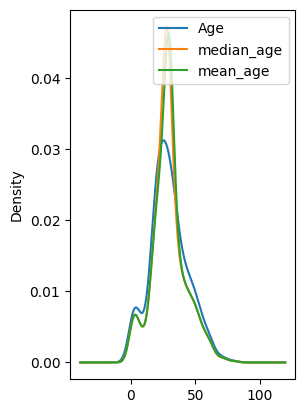

In [15]:
fig = plt.figure()
ax = fig.add_subplot(121)

# Original variance distribution 
X_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the median 
X_train['median_age'].plot(kind='kde',ax=ax)

# variable imputed with the mean 
X_train['mean_age'].plot(kind='kde',ax=ax)

# add legends 
lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

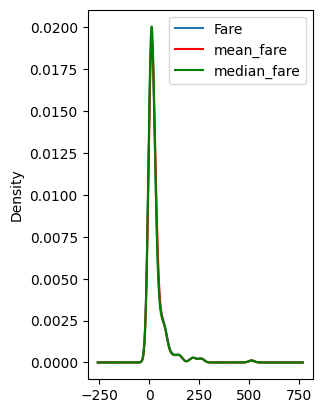

In [16]:
fig = plt.figure()
ax = fig.add_subplot(122)

# original fare column 
X_train['Fare'].plot(kind='kde',ax=ax)

# variable with mean 
X_train['mean_fare'].plot(kind='kde',ax=ax,color='red')

#variable with median 
X_train['median_fare'].plot(kind='kde',ax=ax,color='green')

lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [17]:
X_train.cov()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
mean_age,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
median_age,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
mean_fare,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
median_fare,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [18]:
X_train.corr()

,Age,Fare,Family,mean_age,median_age,mean_fare,median_fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
mean_age,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
median_age,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
mean_fare,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
median_fare,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

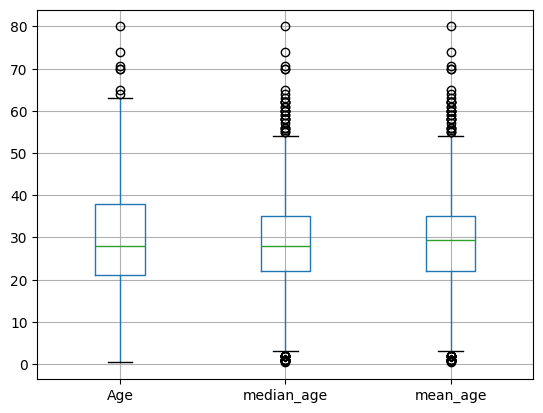

In [19]:
X_train[['Age','median_age','mean_age']].boxplot() # to many new outliers get formed when we fill missing values 

<Axes: >

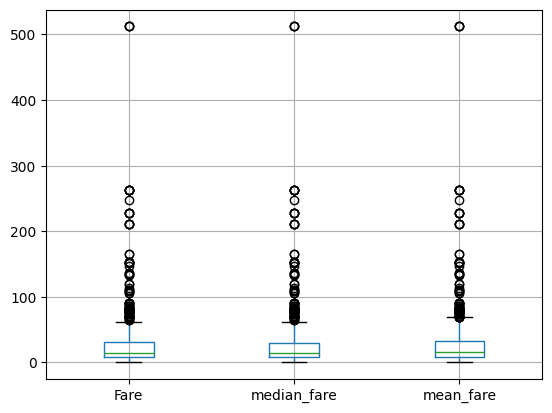

In [20]:
X_train[['Fare','median_fare','mean_fare']].boxplot()

## Using sklearn 

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [23]:
trf = ColumnTransformer([
    ('trf1',imputer1,['Fare']),
    ('trf2',imputer2,['Age'])
],remainder='passthrough')

In [24]:
trf.fit(X_train)

,transformers,"[('trf1', ...), ('trf2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [25]:
trf.named_transformers_['trf1'].statistics_

array([14.4])

In [26]:
trf.named_transformers_['trf2'].statistics_

array([29.49884615])

In [27]:
X_train_trf = trf.transform(X_train)
X_test_trf = trf.transform(X_test)

In [28]:
X_train_trf

array([[ 28.5   ,  45.5   ,   0.    ],
       [ 13.    ,  23.    ,   0.    ],
       [  7.925 ,  32.    ,   0.    ],
       ...,
       [ 14.4   ,  41.    ,   2.    ],
       [120.    ,  14.    ,   3.    ],
       [ 77.2875,  21.    ,   1.    ]], shape=(712, 3))